In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from  torch.utils.data import DataLoader
import torchvision.datasets as datasets
import torchvision.transforms as transforms


### Step-1: - Set the device and HyperParameters

In [2]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
device = torch.device(device)
print(f"Using Device {device}")

Using Device mps


#### Step-2: - Load the Dataset

In [3]:
from pathlib import Path
def find_project_root(start=None, markers=("pyproject.toml", ".git", "requirements.txt", ".gitignore")):
    p = Path(start or Path.cwd()).resolve()
    for cur in [p, *p.parents]:
        if any((cur / m).exists() for m in markers):
            return cur
    return p
BASE_CODE_DIR_PATH = find_project_root()
DATASET_DIR = BASE_CODE_DIR_PATH / 'datasets'
DATASET_DIR, BASE_CODE_DIR_PATH

(PosixPath('/Users/vedaangchopra/all_data/complete_technical_work/Reference and Learning Content/Deep-Learning/datasets'),
 PosixPath('/Users/vedaangchopra/all_data/complete_technical_work/Reference and Learning Content/Deep-Learning'))

### Using the Food-101 Dataset
The Food-101 is a challenging data set of 101 food categories with 101,000 images. For each class, 250 manually reviewed test images are provided as well as 750 training images. On purpose, the training images were not cleaned, and thus still contain some amount of noise. This comes mostly in the form of intense colors and sometimes wrong labels. All images were rescaled to have a maximum side length of 512 pixels.

In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
batch_size = 128

In [5]:
train_data = datasets.Food101(root =DATASET_DIR, download = True, transform= transform, split="train" )
train_data


Dataset Food101
    Number of datapoints: 75750
    Root location: /Users/vedaangchopra/all_data/complete_technical_work/Reference and Learning Content/Deep-Learning/datasets
    split=train
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )

In [6]:
test_data = datasets.Food101(root =DATASET_DIR, download = True, transform= transform, split="test" )

In [7]:
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

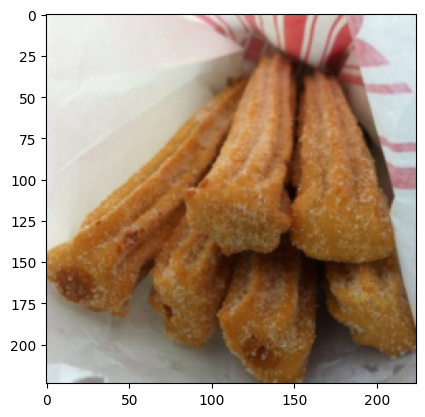

In [8]:
from PIL import Image
import matplotlib.pyplot as plt

plt.imshow(train_data[1][0].permute(1, 2, 0))
plt.show()

In [9]:
print(train_data[0][0].shape)
input_channels= 3
output_classes =101

learning_rate = 1e-4
num_epochs = 5

torch.Size([3, 224, 224])


### Step-3: - Create CNN Architecture

In [10]:
class CNN(nn.Module):
    # in_channels -> RGB mode of the images
    ## num_classes -> Output number of classes
    
    
    ## Here conv2d: -  Used for 2D data like images; Input shape in PyTorch: [N, C, H, W]
    ### Conv3d: - Used for 3D data like videos or medical volumes; Input shape in PyTorch: [N, C, D, H, W]
    
    
    ### nn.ReLU() -> Adds Non Linearity 
    ### MaxPool -> downsamples the image


    ### nn.AdaptiveAvgPool2d((1, 1)) -> turns each feature map into a single number ; this is cleaner than manually calculating huge flattened sizes
    
    
    ## nn.Flatten() -> changes [B, 256, 1, 1] into [B, 256]
    def __init__(self, in_channels:int, num_classes:int):
        super(CNN, self).__init__()
        
        ### Wraping up Convolution layers as one group 
        self.features = nn.Sequential(
            # Input: [B, 3, 512, 512]
            nn.Conv2d(in_channels=in_channels, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # [B, 32, 256, 256]
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # [B, 64, 128, 128]
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # [B, 128, 64, 64]
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # [B, 256, 32, 32]
            nn.AdaptiveAvgPool2d((1, 1))
            # [B, 256, 1, 1]
            
        ) 
        self.classifier = nn.Sequential(
            nn.Flatten(), ### This is used instead of Reshape
            
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        # print(x.shape)
        x= self.classifier(x)
        return x 


### Random Test. 
# The unsqueeze function added a batch to this.
# model_test = CNN(in_channels= input_channels, num_classes =output_classes).to(device)
# print(model_test.forward(train_data[0][0].unsqueeze(0).to(device)).shape)

### Step-4: - Defining loss and training Loop

In [11]:
model = CNN(in_channels= input_channels, num_classes =output_classes).to(device)
loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr = learning_rate)

In [12]:
## Tracking all train, test loss and accuracy in array
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

#### Writing the training function 

In [13]:
from IPython.display import clear_output, display
import matplotlib.pyplot as plt

In [14]:
def train_one_epoch(model, dataloader, loss_fn, optimizer, device):
    ### Step-1: - Set model to training mode
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0,0
    # 
    for x, y in dataloader:
        
        ## Step-2: - Move input and targets to same device
        x,y= x.to(device), y.to(device)
        
        ### Step-3: - Clears old gradients, PyTorch accumulates gradients by default. So if you do not zero them out, gradients from previous batches keep adding up, which is usually wrong.
        optimizer.zero_grad()
        
        
        ### Step-3: - Do the forward pass
        forward_prop_result = model(x)
        
        ## Step-4: - Calcuate the loss on that 
        loss_val = loss_func(forward_prop_result, y)
        
        
        # Step-5: - Do the backward prop
        loss_val.backward()
        
        
        ## Step-6: - Update the model weights after the backward prop
        optimizer.step()
        
        ## Step-7: - Calculating loss for all batches and accuracy for all batches
        
        # Adds this batch’s loss to the running total. Because loss.item() is usually the average loss for the batch.
        total_loss += loss_val.item() * x.size(0)
        
        preds = forward_prop_result.argmax(dim=1)
        total_correct +=(preds==y).sum().item()
        total_samples +=y.size(0)
    
    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc

    

In [15]:
### Writing accuracy function, training loop function and plot function to print while training on test data
def evaluation_function(model, dataloader, loss_fn, device, split="Test"):
    
    ### Step-1: - Set the model to evaluate mode
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)

            ## Forward Pass
            logits = model(x)
            loss = loss_fn(logits, y)
            
            total_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            
            total_correct +=(preds==y).sum().item()
            total_samples +=y.size(0)
    
    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    print(f"{split} Loss: {avg_loss:.4f} | {split} Acc: {avg_acc:.4f}")
    return avg_loss, avg_acc



In [16]:
def plot_history(history, epoch, num_epochs):
    clear_output(wait=True)
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    
    ### Training Loss
    axes[0].plot(epochs, history["train_loss"], marker="o", label="Train Loss")
    axes[0].plot(epochs, history["test_loss"], marker="o", label="Test Loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    
    ## Testing Loss 
    axes[1].plot(epochs, history["train_acc"], marker="o", label="Train Acc")
    axes[1].plot(epochs, history["test_acc"], marker="o", label="Test Acc")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    fig.suptitle(f"Training Progress: Epoch {epoch}/{num_epochs}")
    plt.tight_layout()
    display(fig)
    plt.close(fig)



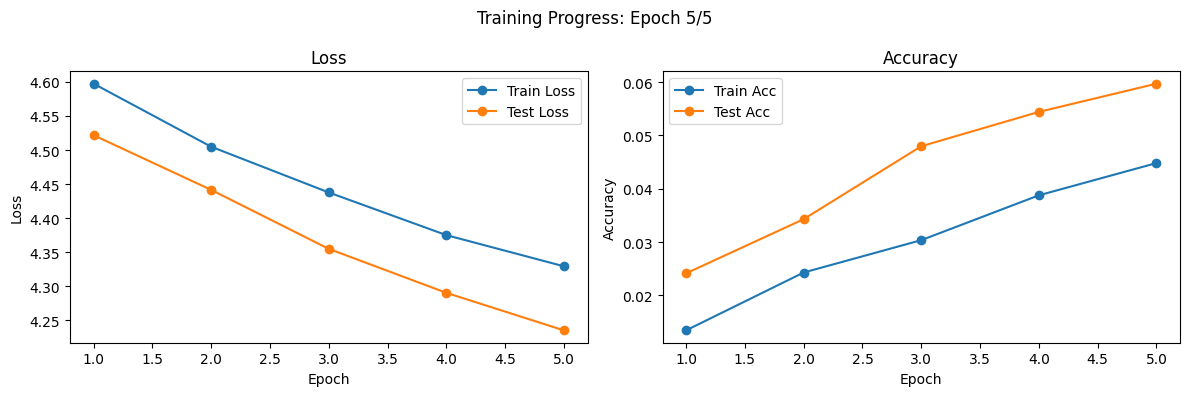

Epoch 5/5 | Train Loss: 4.3295 | Train Acc: 0.0448 | Test Loss: 4.2355 | Test Acc: 0.0597


In [17]:
for epoch in range(num_epochs):
    
    train_loss, train_acc = train_one_epoch(model, train_loader, loss_func, optimizer, device)
    
    test_loss, test_acc = evaluation_function(model, train_loader, loss_func, device, split="Test")
    
    ### Append them in history dictionary for plotting.....
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)
    
    plot_history(history, epoch + 1, num_epochs)

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}"
    )

    